# Proyecto 9 - Preprocesamiento para Machine Learning

**Actividad 2.1 - Data Science Showcase**  
**Equipo:** B  
**Alumno responsable:** José Carlos Hernández Ballado  
**Dataset adaptado:** Gapminder World completo (1952-2007)

## Objetivo

Preparar el mismo dataset Gapminder completo utilizado por el equipo para que pueda emplearse en un modelo de Machine Learning. Se aplican las técnicas solicitadas en el PDF de la actividad: separación de variables, división de entrenamiento y prueba, escalado de variables numéricas y transformación One Hot Encoding de una variable categórica.

> Relación con el repositorio del curso: el flujo general de Machine Learning se encuentra en la carpeta `11.Machine Learning`. Esta adaptación sustituye el dataset Boston House Prices por Gapminder y agrega explícitamente el escalado y el One Hot Encoding solicitados en el Proyecto 9 del PDF.

| | Original (Frank Andrade) | Adaptación (este notebook) |
|---|---|---|
| Dataset | Boston House Prices | Gapminder World completo |
| Variables | Numéricas | Numéricas y categórica |
| Preparación | Selección directa de columnas | Escalado y One Hot Encoding |
| Finalidad | Regresión del valor de vivienda | Clasificación educativa de esperanza de vida |

## 1. Importación de librerías

- **pandas** permite cargar y manipular el DataFrame.
- **train_test_split** divide los datos sin mezclar entrenamiento y prueba.
- **StandardScaler** coloca las variables numéricas en una escala comparable.
- **OneHotEncoder** convierte categorías de texto en columnas numéricas.
- **ColumnTransformer** aplica transformaciones diferentes según el tipo de columna.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option('display.max_columns', 30)
Path('figuras').mkdir(exist_ok=True)
print('Librerías importadas correctamente.')

Librerías importadas correctamente.


## 2. Replicación y explicación del código original

En la carpeta `11.Machine Learning` del repositorio, Frank Andrade utiliza `Boston House Prices.csv`. Su flujo principal es:

```python
df_boston = pd.read_csv('Boston House Prices.csv')
y = df_boston['Value']
X = df_boston[['Rooms', 'Distance']]
lm = LinearRegression()
lm.fit(X, y)
lm.score(X, y)
```

El autor selecciona dos variables independientes numéricas (`Rooms` y `Distance`) para estimar la variable dependiente `Value`. Como ambas entradas ya son numéricas, el ejemplo original no necesita One Hot Encoding. En el caso adaptado se conserva la lógica de separar predictores (`X`) y objetivo (`y`), pero se añade un preprocesador porque Gapminder contiene variables numéricas y categóricas.

## 3. Caso adaptado: carga de Gapminder

Se utiliza exactamente `gapminder_full.csv`, el archivo empleado en el Proyecto 7 del equipo. Contiene 1,704 observaciones correspondientes a 142 países en 12 años, desde 1952 hasta 2007.

In [2]:
rutas_posibles = [
    Path('gapminder_full.csv'),
    Path('/content/gapminder_full.csv'),
]

ruta_dataset = next((ruta for ruta in rutas_posibles if ruta.exists()), None)
if ruta_dataset is None:
    raise FileNotFoundError('Sube gapminder_full.csv a Colab o colócalo junto al notebook.')

df = pd.read_csv(ruta_dataset)

# El archivo original incluye una columna de índice sin nombre; no es una variable real.
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
if '' in df.columns:
    df = df.drop(columns=[''])

print(f'Archivo cargado: {ruta_dataset}')
print(f'Dimensiones: {df.shape[0]} filas y {df.shape[1]} columnas')
df.head()

Archivo cargado: gapminder_full.csv
Dimensiones: 1704 filas y 6 columnas


       country  year  population continent  life_exp     gdp_cap
0  Afghanistan  1952     8425333      Asia    28.801  779.445314
1  Afghanistan  1957     9240934      Asia    30.332  820.853030
2  Afghanistan  1962    10267083      Asia    31.997  853.100710
3  Afghanistan  1967    11537966      Asia    34.020  836.197138
4  Afghanistan  1972    13079460      Asia    36.088  739.981106

## 4. Auditoría y limpieza

Antes del preprocesamiento se revisan tipos de datos, valores faltantes y duplicados. Esta auditoría evita alimentar el modelo con registros incorrectos.

In [3]:
print('Tipos de datos:')
print(df.dtypes)
print('\nValores faltantes por columna:')
print(df.isna().sum())
print(f'\nFilas duplicadas: {df.duplicated().sum()}')

df = df.drop_duplicates().copy()
print(f'Dimensiones después de la limpieza: {df.shape}')

Tipos de datos:
country        object
year            int64
population      int64
continent      object
life_exp      float64
gdp_cap       float64
dtype: object

Valores faltantes por columna:
country       0
year          0
population    0
continent     0
life_exp      0
gdp_cap       0
dtype: int64

Filas duplicadas: 0
Dimensiones después de la limpieza: (1704, 6)


## 5. Definición del problema de Machine Learning

Se propone un problema de **clasificación binaria**: identificar si una observación país-año posee una esperanza de vida alta respecto al conjunto histórico completo.

La mediana de `life_exp` se usa como umbral porque divide equilibradamente los países. Se crea:

- `alta_esperanza_vida = 1`: esperanza de vida igual o superior a la mediana.
- `alta_esperanza_vida = 0`: esperanza de vida inferior a la mediana.

Después de crear el objetivo se elimina `life_exp` de las variables predictoras. Dejarla sería **fuga de información**, porque el modelo recibiría directamente el dato utilizado para definir la respuesta.

Umbral (mediana): 60.71 años

Distribución de la variable objetivo:
alta_esperanza_vida
Baja    852
Alta    852
Name: count, dtype: int64


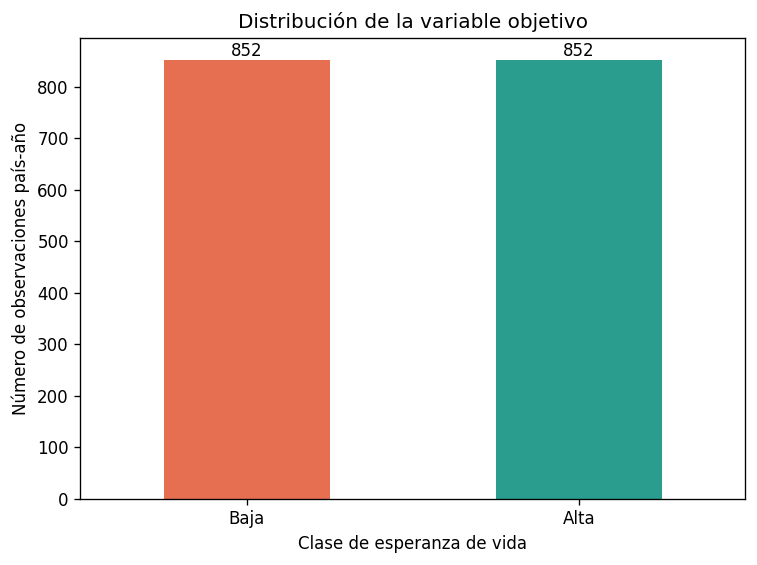

In [4]:
umbral_vida = df['life_exp'].median()
df['alta_esperanza_vida'] = (df['life_exp'] >= umbral_vida).astype(int)

print(f'Umbral (mediana): {umbral_vida:.2f} años')
print('\nDistribución de la variable objetivo:')
conteo_objetivo = df['alta_esperanza_vida'].value_counts().sort_index().rename(index={0: 'Baja', 1: 'Alta'})
print(conteo_objetivo)

ax = conteo_objetivo.plot(
    kind='bar', color=['#E76F51', '#2A9D8F'], rot=0,
    title='Distribución de la variable objetivo'
)
ax.set_xlabel('Clase de esperanza de vida')
ax.set_ylabel('Número de observaciones país-año')
for contenedor in ax.containers:
    ax.bar_label(contenedor)
plt.tight_layout()
plt.savefig('figuras/01_distribucion_objetivo.png', dpi=160, bbox_inches='tight')
plt.show()

## 6. Selección de variables

Se utilizan:

- Numéricas: `year`, `population` y `gdp_cap`.
- Categórica: `continent`.

No se utiliza `country` porque funciona como identificador y crearía una columna distinta para cada país.

In [5]:
variables_numericas = ['year', 'population', 'gdp_cap']
variables_categoricas = ['continent']
variable_objetivo = 'alta_esperanza_vida'

X = df[variables_numericas + variables_categoricas].copy()
y = df[variable_objetivo].copy()

print('Variables predictoras:', list(X.columns))
print('Variable objetivo:', variable_objetivo)
X.head()

Variables predictoras: ['year', 'population', 'gdp_cap', 'continent']
Variable objetivo: alta_esperanza_vida


   year  population     gdp_cap continent
0  1952     8425333  779.445314      Asia
1  1957     9240934  820.853030      Asia
2  1962    10267083  853.100710      Asia
3  1967    11537966  836.197138      Asia
4  1972    13079460  739.981106      Asia

## 7. División de entrenamiento y prueba

El 80% de los registros se utiliza para entrenamiento y el 20% para prueba. `stratify=y` conserva la proporción de las dos clases. El preprocesador se ajustará únicamente con entrenamiento para evitar fuga de información.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print('Entrenamiento:', X_train.shape)
print('Prueba:', X_test.shape)
print('\nProporción de clase alta:')
print(f'Entrenamiento: {y_train.mean():.3f}')
print(f'Prueba: {y_test.mean():.3f}')

Entrenamiento: (1363, 4)
Prueba: (341, 4)

Proporción de clase alta:
Entrenamiento: 0.500
Prueba: 0.499


## 8. Construcción del preprocesador

Para las variables numéricas se aplica:

1. Imputación por mediana, en caso de que aparezcan valores faltantes.
2. `StandardScaler`, que centra los datos alrededor de 0 y los escala.

Para `continent` se aplica:

1. Imputación por moda.
2. `OneHotEncoder`, que crea columnas binarias como `continent_Africa` y `continent_Europe`.

In [7]:
pipeline_numerico = Pipeline(steps=[
    ('imputador', SimpleImputer(strategy='median')),
    ('escalador', StandardScaler()),
])

try:
    codificador = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:  # Compatibilidad con versiones anteriores de scikit-learn
    codificador = OneHotEncoder(handle_unknown='ignore', sparse=False)

pipeline_categorico = Pipeline(steps=[
    ('imputador', SimpleImputer(strategy='most_frequent')),
    ('onehot', codificador),
])

preprocesador = ColumnTransformer(transformers=[
    ('numericas', pipeline_numerico, variables_numericas),
    ('categoricas', pipeline_categorico, variables_categoricas),
])

print(preprocesador)

ColumnTransformer(transformers=[('numericas',
                                 Pipeline(steps=[('imputador',
                                                  SimpleImputer(strategy='median')),
                                                 ('escalador',
                                                  StandardScaler())]),
                                 ['year', 'population', 'gdp_cap']),
                                ('categoricas',
                                 Pipeline(steps=[('imputador',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['continent'])])


## 9. Aplicación del escalado y One Hot Encoding

`fit_transform` se utiliza solamente con entrenamiento. Para prueba se usa `transform`, aplicando exactamente los parámetros aprendidos del conjunto de entrenamiento.

In [8]:
X_train_procesado = preprocesador.fit_transform(X_train)
X_test_procesado = preprocesador.transform(X_test)

nombres_variables = preprocesador.get_feature_names_out()
X_train_procesado_df = pd.DataFrame(
    X_train_procesado,
    columns=nombres_variables,
    index=X_train.index,
)

print('Forma original de entrenamiento:', X_train.shape)
print('Forma después del preprocesamiento:', X_train_procesado_df.shape)
print('\nVariables generadas:')
print(list(nombres_variables))
X_train_procesado_df.head()

Forma original de entrenamiento: (1363, 4)
Forma después del preprocesamiento: (1363, 8)

Variables generadas:
['numericas__year', 'numericas__population', 'numericas__gdp_cap', 'categoricas__continent_Africa', 'categoricas__continent_Americas', 'categoricas__continent_Asia', 'categoricas__continent_Europe', 'categoricas__continent_Oceania']


      numericas__year  numericas__population  numericas__gdp_cap  \
891         -0.733313              -0.261907           -0.660939   
911          1.605395              -0.218255            0.496125   
1076         0.728380              -0.087146           -0.642157   
513          1.020718               0.275601           -0.681105   
678          0.143703              -0.175419            0.545950   

      categoricas__continent_Africa  categoricas__continent_Americas  \
891                             1.0                              0.0   
911                             1.0                              0.0   
1076                            0.0                              0.0   
513                             1.0                              0.0   
678                             0.0                              0.0   

      categoricas__continent_Asia  categoricas__continent_Europe  \
891                           0.0                            0.0   
911                   

## 10. Comprobación de las transformaciones

Las variables escaladas deben tener media cercana a 0 y desviación estándar cercana a 1 en entrenamiento. Las columnas de continente deben contener ceros y unos. También se genera una imagen comparativa para documentar el efecto del escalado.

Resumen de las variables escaladas:
      numericas__year  numericas__population  numericas__gdp_cap
mean              0.0                    0.0                -0.0
std               1.0                    1.0                 1.0

Vista de las columnas One Hot Encoding:
      categoricas__continent_Africa  categoricas__continent_Americas  \
891                             1.0                              0.0   
911                             1.0                              0.0   
1076                            0.0                              0.0   
513                             1.0                              0.0   
678                             0.0                              0.0   

      categoricas__continent_Asia  categoricas__continent_Europe  \
891                           0.0                            0.0   
911                           0.0                            0.0   
1076                          1.0                            0.0   
513                    

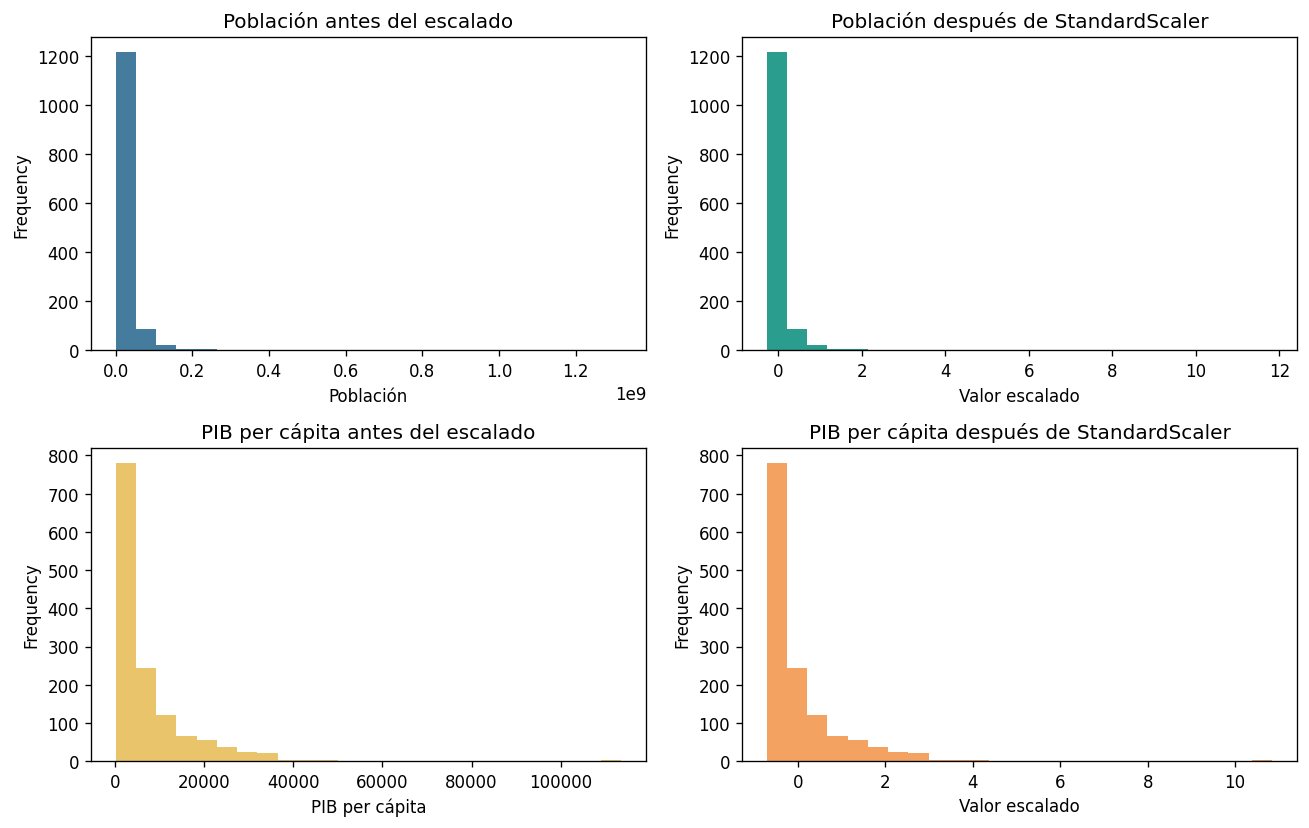

In [9]:
columnas_num_procesadas = [f'numericas__{col}' for col in variables_numericas]
print('Resumen de las variables escaladas:')
print(X_train_procesado_df[columnas_num_procesadas].agg(['mean', 'std']).round(3))

print('\nVista de las columnas One Hot Encoding:')
columnas_onehot = [c for c in X_train_procesado_df.columns if c.startswith('categoricas__')]
print(X_train_procesado_df[columnas_onehot].head())

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
X_train['population'].plot(kind='hist', bins=25, ax=axes[0, 0], color='#457B9D')
axes[0, 0].set_title('Población antes del escalado')
axes[0, 0].set_xlabel('Población')
X_train_procesado_df['numericas__population'].plot(kind='hist', bins=25, ax=axes[0, 1], color='#2A9D8F')
axes[0, 1].set_title('Población después de StandardScaler')
axes[0, 1].set_xlabel('Valor escalado')
X_train['gdp_cap'].plot(kind='hist', bins=25, ax=axes[1, 0], color='#E9C46A')
axes[1, 0].set_title('PIB per cápita antes del escalado')
axes[1, 0].set_xlabel('PIB per cápita')
X_train_procesado_df['numericas__gdp_cap'].plot(kind='hist', bins=25, ax=axes[1, 1], color='#F4A261')
axes[1, 1].set_title('PIB per cápita después de StandardScaler')
axes[1, 1].set_xlabel('Valor escalado')
plt.tight_layout()
plt.savefig('figuras/02_antes_y_despues_escalado.png', dpi=160, bbox_inches='tight')
plt.show()

## 11. Validación opcional con un modelo

El objetivo del Proyecto 9 es el preprocesamiento. No obstante, se entrena una regresión logística sencilla para comprobar que la matriz transformada puede utilizarse sin errores en un modelo de clasificación. El resultado es una validación educativa, no un modelo definitivo.

Accuracy de comprobación: 0.845

Matriz de confusión:
[[147  24]
 [ 29 141]]

Reporte de clasificación:
              precision    recall  f1-score   support

        Baja       0.84      0.86      0.85       171
        Alta       0.85      0.83      0.84       170

    accuracy                           0.84       341
   macro avg       0.84      0.84      0.84       341
weighted avg       0.84      0.84      0.84       341



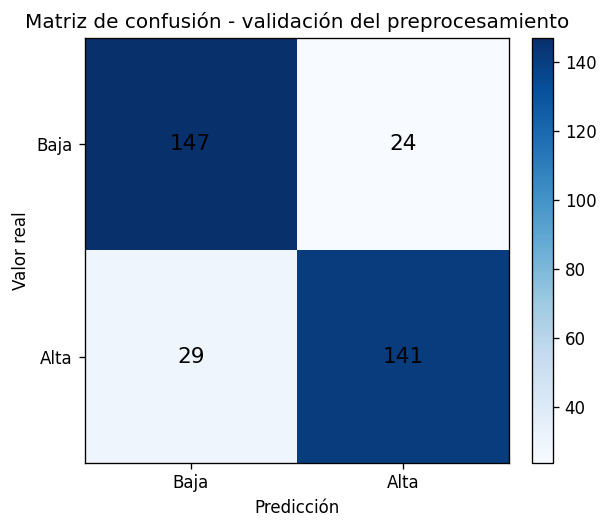

In [10]:
modelo = LogisticRegression(max_iter=1000, random_state=42)
modelo.fit(X_train_procesado, y_train)
predicciones = modelo.predict(X_test_procesado)

exactitud = accuracy_score(y_test, predicciones)
print(f'Accuracy de comprobación: {exactitud:.3f}')
print('\nMatriz de confusión:')
matriz = confusion_matrix(y_test, predicciones)
print(matriz)
print('\nReporte de clasificación:')
print(classification_report(y_test, predicciones, target_names=['Baja', 'Alta']))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
imagen = ax.imshow(matriz, cmap='Blues')
for i in range(matriz.shape[0]):
    for j in range(matriz.shape[1]):
        ax.text(j, i, matriz[i, j], ha='center', va='center', fontsize=13)
ax.set_xticks([0, 1], labels=['Baja', 'Alta'])
ax.set_yticks([0, 1], labels=['Baja', 'Alta'])
ax.set_xlabel('Predicción')
ax.set_ylabel('Valor real')
ax.set_title('Matriz de confusión - validación del preprocesamiento')
fig.colorbar(imagen, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig('figuras/03_matriz_confusion.png', dpi=160, bbox_inches='tight')
plt.show()

## Conclusiones

1. El dataset Gapminder completo contiene **1,704 observaciones, 142 países y 12 años** y no presenta valores faltantes, pero el flujo incluye imputadores para que el preprocesamiento sea reproducible ante datos futuros.
2. `year`, `population` y `gdp_cap` se escalaron con `StandardScaler`.
3. `continent` se transformó a columnas numéricas mediante One Hot Encoding.
4. El ajuste del preprocesamiento se realizó únicamente con los datos de entrenamiento para evitar fuga de información.
5. `life_exp` fue excluida de los predictores porque se utilizó para construir la variable objetivo.
6. El dataset procesado quedó listo para utilizarse con algoritmos de Machine Learning.

### Respuesta breve para exposición

“Tomamos el mismo Gapminder completo utilizado por el equipo y adaptamos el flujo de Machine Learning del repositorio. Escalamos año, población y PIB per cápita, convertimos continente con One Hot Encoding y separamos entrenamiento y prueba. El preprocesador se ajustó solo con entrenamiento para evitar fuga de información.”